# Notebook 3: Attention-Analyse
**Kurs:** Mechanistic Interpretability  
**Modell:** EleutherAI/pythia-410m  
**Ziel:** Attention-Muster visualisieren und wichtige Heads identifizieren.

> **Aufgabe:** Implementiere die Zellen schrittweise. Hilfreiche Dokumentation:
> - HuggingFace `output_attentions`: https://huggingface.co/docs/transformers/main_classes/output
> - Matplotlib Imshow: https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.imshow.html
> - NumPy argsort: https://numpy.org/doc/stable/reference/generated/numpy.argsort.html

## Hintergrund: Attention-Mechanismus

In jedem Transformer-Layer berechnen **Attention Heads** gewichtete Summen über alle Token-Positionen:

```
A = softmax( QK^T / sqrt(d_head) )
```

Die Attention-Matrix A hat die Form **(seq × seq)**:
- Zeile i: Welche Positionen achtet Position i?
- Spalte j: Von welchen Positionen wird Position j beachtet?

In der Mechanistic Interpretability fragen wir: **Welche Heads implementieren welche Funktion?**

Bekannte Head-Typen:
- **Previous Token Heads**: Achten auf das unmittelbar vorherige Token
- **Induction Heads**: Implementieren Muster-Vervollständigung ("A...B...A → B")
- **Name Mover Heads**: Transportieren semantische Information zur Ausgabe-Position

## 1. Setup und Modell laden

In [84]:
%load_ext autoreload
%autoreload 2

# Standard-library imports used only for notebook bootstrapping.
# The analysis logic itself lives in the utility modules imported below.
import sys
import importlib
from pathlib import Path
from IPython.display import Image, display

# Add the assignment utility directory to the import path.
utils_dir = Path.cwd().parent / "utils"
if not (utils_dir / "config.py").exists():
    raise FileNotFoundError(f"Could not find the assignment utils directory: {utils_dir}")

if str(utils_dir) not in sys.path:
    sys.path.insert(0, str(utils_dir))

# Reload utility modules so notebook reruns pick up local code changes.
import config
import model_utils
import plotting_utils
import attention_utils

for module in [config, model_utils, plotting_utils, attention_utils]:
    importlib.reload(module)

# Import high-level attention-analysis functions. Heavy computation and plotting
# stay in the utility files so the notebook remains readable.
from model_utils import load_model_and_tokenizer, setup_environment
from attention_utils import (
    analyze_induction_heads,
    analyze_cad_hu_liu_attention_heads,
    analyze_subject_attention,
    print_ranked_heads,
    run_attention_forward_pass,
    plot_selected_attention_heads,
)

# Select the available device and load the same model/tokenizer pair used in
# the rest of the assignment.
device = setup_environment()
model, tokenizer = load_model_and_tokenizer(device)

# Display helper for PNG files produced by plotting utilities.
def display_image(png_name):
    image_path = config.OUTPUT_PNG_DIR / png_name
    if not image_path.exists():
        raise FileNotFoundError(f"PNG image not found in output directory: {image_path}")
    display(Image(filename=str(image_path)))


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
PyTorch-Version : 2.6.0+cu124
Gerät           : cpu


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]


Modell-Architektur:
GPTNeoXForCausalLM(
  (gpt_neox): GPTNeoXModel(
    (embed_in): Embedding(50304, 1024)
    (emb_dropout): Dropout(p=0.0, inplace=False)
    (layers): ModuleList(
      (0-23): 24 x GPTNeoXLayer(
        (input_layernorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (post_attention_layernorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (post_attention_dropout): Dropout(p=0.0, inplace=False)
        (post_mlp_dropout): Dropout(p=0.0, inplace=False)
        (attention): GPTNeoXAttention(
          (query_key_value): Linear(in_features=1024, out_features=3072, bias=True)
          (dense): Linear(in_features=1024, out_features=1024, bias=True)
        )
        (mlp): GPTNeoXMLP(
          (dense_h_to_4h): Linear(in_features=1024, out_features=4096, bias=True)
          (dense_4h_to_h): Linear(in_features=4096, out_features=1024, bias=True)
          (act): GELUActivation()
        )
      )
    )
    (final_layer_norm): LayerNorm

## 2. Forward Pass mit Attention-Gewichten

In [85]:
prompt = "The food was delicious and the service was"

# Run one forward pass with output_attentions=True and keep the decoded tokens
# plus all layer/head attention tensors for the following chapters.
attention_run = run_attention_forward_pass(model, tokenizer, device, prompt)
tokens = attention_run["tokens"]
attentions = attention_run["attentions"]


Prompt tokens (8):
 0: 'The'
 1: ' food'
 2: ' was'
 3: ' delicious'
 4: ' and'
 5: ' the'
 6: ' service'
 7: ' was'

Attention tensors:
Number of attention matrices: 24
outputs.attentions is a tuple with 24 entries.
One tuple entry is returned per transformer layer.
Single head attention matrix size: (8, 8)
Layer 0: (1, 16, 8, 8)
Layer 1: (1, 16, 8, 8)
Layer 2: (1, 16, 8, 8)
Layer 3: (1, 16, 8, 8)
Layer 4: (1, 16, 8, 8)
Layer 5: (1, 16, 8, 8)
Layer 6: (1, 16, 8, 8)
Layer 7: (1, 16, 8, 8)
Layer 8: (1, 16, 8, 8)
Layer 9: (1, 16, 8, 8)
Layer 10: (1, 16, 8, 8)
Layer 11: (1, 16, 8, 8)
Layer 12: (1, 16, 8, 8)
Layer 13: (1, 16, 8, 8)
Layer 14: (1, 16, 8, 8)
Layer 15: (1, 16, 8, 8)
Layer 16: (1, 16, 8, 8)
Layer 17: (1, 16, 8, 8)
Layer 18: (1, 16, 8, 8)
Layer 19: (1, 16, 8, 8)
Layer 20: (1, 16, 8, 8)
Layer 21: (1, 16, 8, 8)
Layer 22: (1, 16, 8, 8)
Layer 23: (1, 16, 8, 8)


### Ergebnisinterpretation

Hier wurde der Prompt tokenisiert und anschließend ein Forward Pass durch das Modell ausgeführt, diesmal mit `output_attentions=True`. Dadurch gibt das Modell nicht nur die normalen Logits zurück, sondern zusätzlich die Attention-Tensoren aller Transformer-Schichten.

Die Ausgabe beginnt mit den Prompt-Tokens. Da die Tokens jetzt mit `tokenizer.decode([token_id])` erzeugt werden, erscheinen Leerzeichen als normale Leerzeichen im Token-Text und nicht mehr als interne Tokenizer-Markierungen wie `Ġ`.

Die Zeile:

```text
Number of attention matrices: 24
```

bedeutet, dass `outputs.attentions` 24 Attention-Einträge enthält. Das passt zur Architektur von Pythia-410M: Das Modell hat 24 Transformer-Schichten, und für jede Schicht wird genau ein Attention-Tensor zurückgegeben.

Die Zeile:

```text
outputs.attentions is a tuple with 24 entries.
```

macht explizit, dass `outputs.attentions` kein einzelner Tensor ist, sondern ein Tupel mit 24 Elementen. Jedes Element dieses Tupels gehört zu einer Transformer-Schicht.

Die Zeile:

```text
Single head attention matrix size: (8, 8)
```

beschreibt die Größe einer einzelnen Attention-Matrix für einen einzelnen Head. In diesem Beispiel besteht der Prompt aus 8 Tokens, daher hat die Matrix die Form `8 x 8`. Jede Zeile steht für eine Query-Position, also das Token, das Aufmerksamkeit verteilt. Jede Spalte steht für eine Key-Position, also ein Token, auf das geachtet werden kann.

Eine Layer-Ausgabe wie:

```text
Layer 8: (1, 16, 8, 8)
```

bedeutet konkret:

```text
(batch_size, number_of_heads, query_positions, key_positions)
```

Für dieses Beispiel heißt das:

- `1`: Es wurde genau ein Prompt gleichzeitig verarbeitet.
- `16`: Jede Schicht besitzt 16 Attention Heads.
- `8`: Der Prompt besteht aus 8 Query-Positionen.
- `8`: Der Prompt besteht aus 8 Key-Positionen.

Da das Modell kausal arbeitet, dürfen Tokens nicht auf zukünftige Tokens achten. Die Attention-Matrix enthält daher vor allem Aufmerksamkeit auf vorherige oder aktuelle Token-Positionen. Diese Attention-Tensoren bilden die Grundlage für die nächsten Kapitel, in denen einzelne Heads visualisiert und danach systematisch nach starken Subject-Attention- oder Induction-Mustern durchsucht werden.


## 3. Einzelne Attention-Heads visualisieren

Unchanged file: attention_head_grid.png


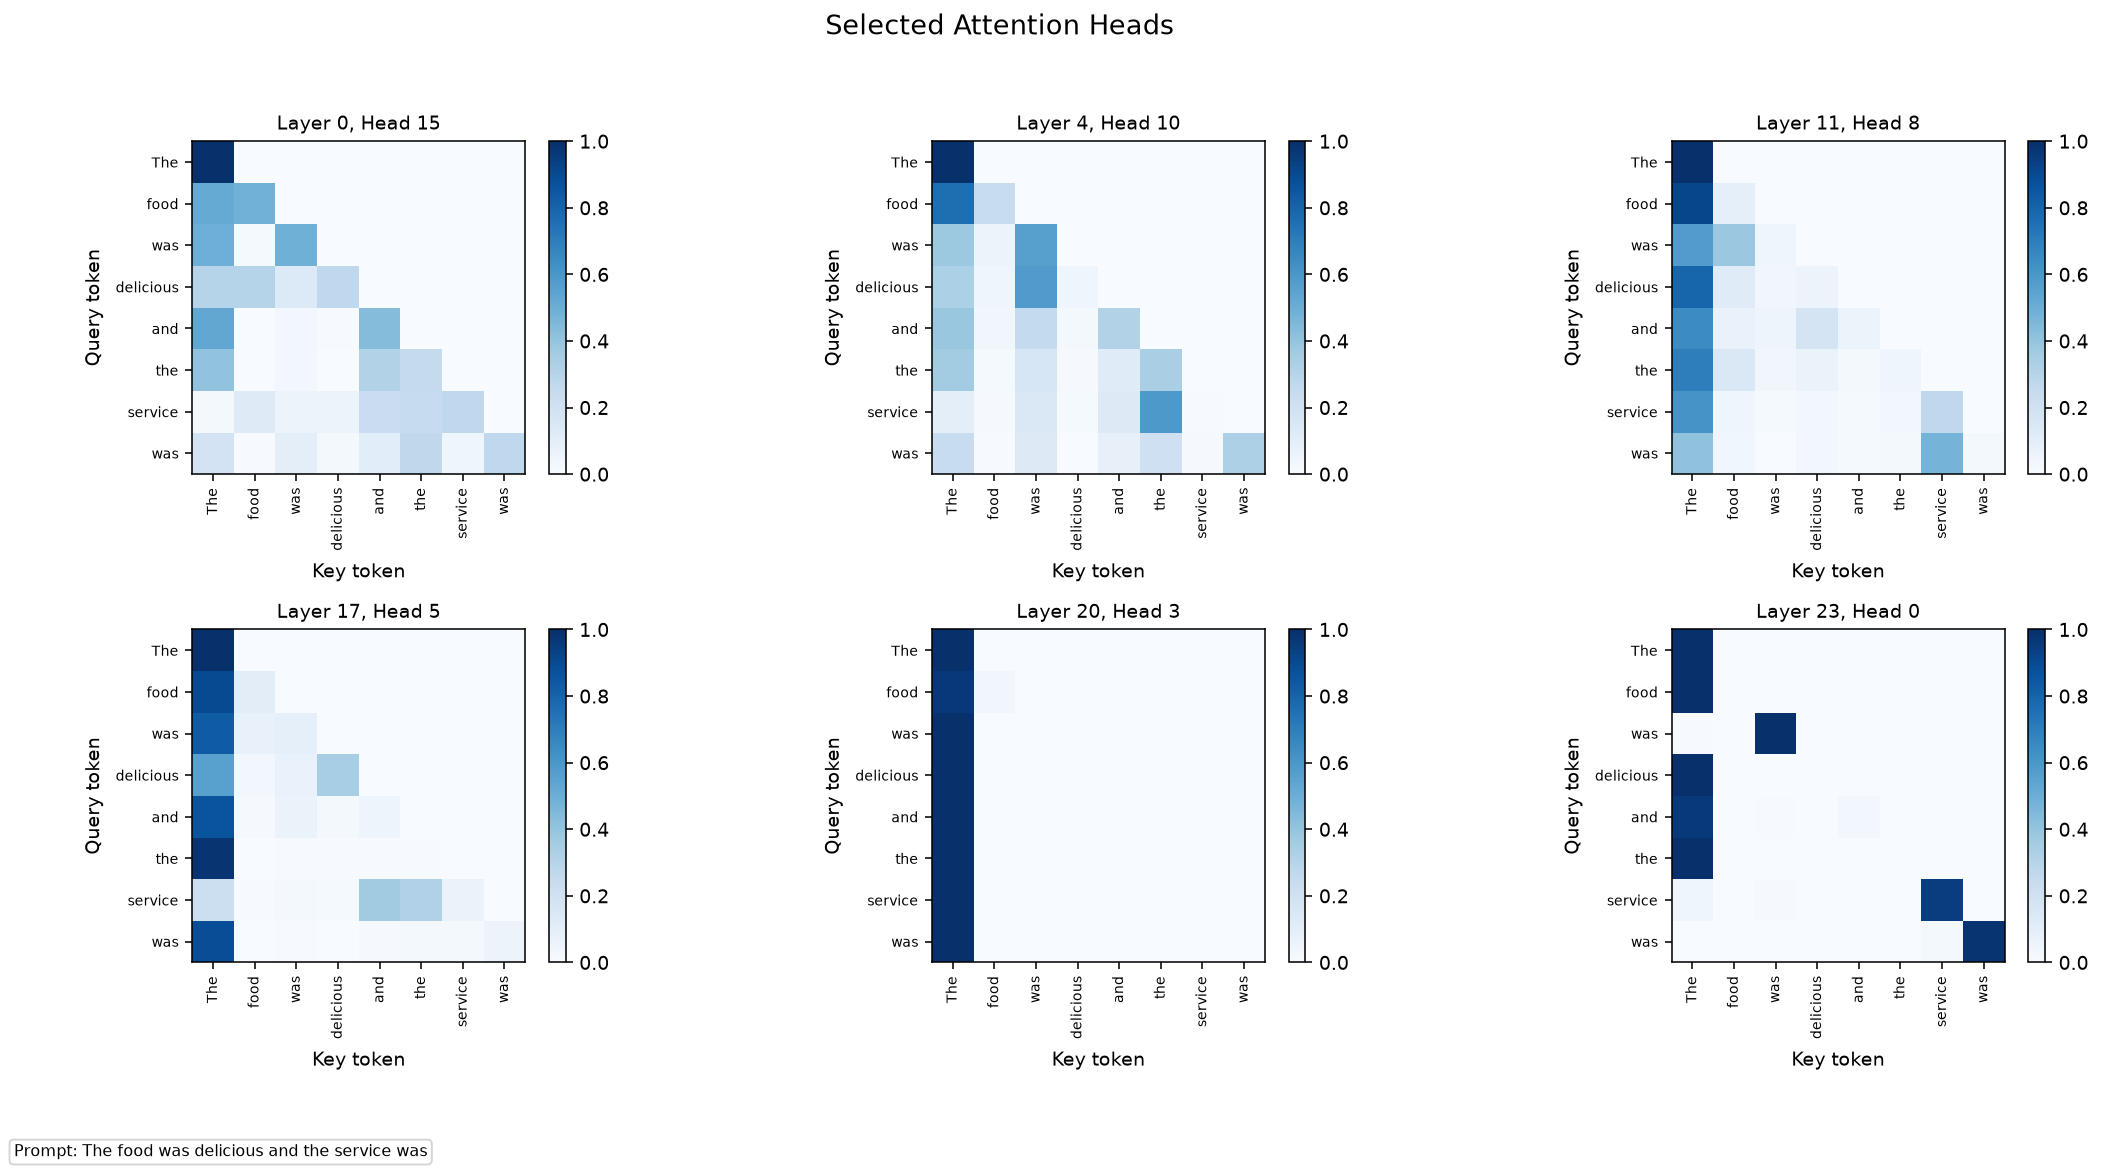

In [86]:
# Choose the layer/head pairs to inspect in the attention-head grid.
heads_to_plot = [
    (0, 15),
    (4, 10),
    (11, 8),
    (17, 5),
    (20, 3),
    (23, 0),
]

# Save and display the selected attention heads.
plot_selected_attention_heads(attentions, tokens, prompt, head_specs=heads_to_plot)
display_image(config.ATTENTION_HEAD_GRID_PATH.name)


## 4. Attention auf Subject-Token Analyse

Subject token ' delicious' found at position 3.
Rank   Layer   Head   Attention weight to ' delicious'
--------------------------------------
1      6       3      0.835123
2      10      13     0.500263
3      0       13     0.371467
4      7       7      0.358672
5      8       7      0.353302
6      19      15     0.349163
7      4       7      0.317502
8      3       15     0.297037
9      12      0      0.274218
10     7       3      0.271510
Unchanged file: attention_subject_heatmap.png


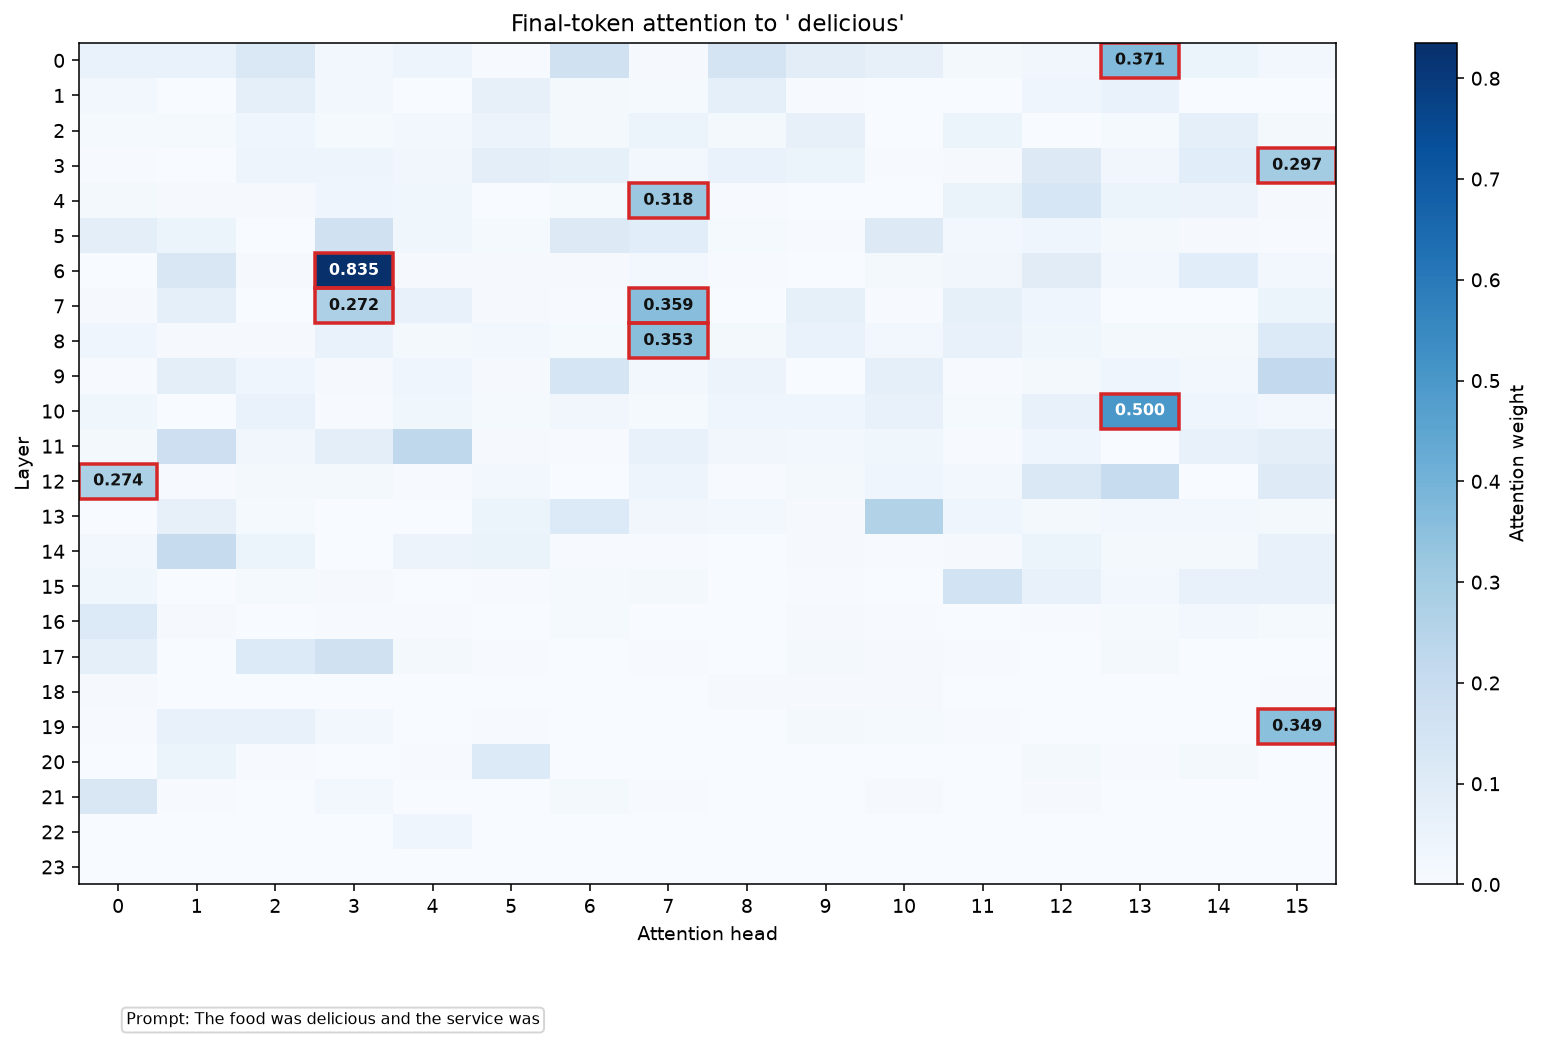

In [87]:
# Measure how strongly the final token attends to the selected subject token across all heads.
subject_token = " delicious"
subject_attention_result = analyze_subject_attention(
    attentions,
    tokens,
    prompt=prompt,
    subject_token=subject_token,
    top_k=10,
    filename_or_path=config.ATTENTION_SUBJECT_HEATMAP_PATH,
)

# Display the layer/head heatmap generated by the subject-attention analysis.
# The outlined cells mark the same top-k heads printed in the ranking table.
display_image(config.ATTENTION_SUBJECT_HEATMAP_PATH.name)


## 5. Counterfactual Sentiment Dataset Attention Head Analyse
Die bisherige Logit-Lens-Analyse hat gezeigt, dass sentimentbezogene Informationen in Pythia-410M schrittweise über die Transformer-Schichten hinweg aufgebaut werden. Insbesondere die Analyse der Logit-Differenzen auf dem Counterfactually Augmented Dataset (CAD) deutete darauf hin, dass sich positive und negative Repräsentationen erst in den mittleren und späten Schichten deutlich voneinander trennen. Die Logit-Lens-Methode erlaubt jedoch lediglich die Untersuchung der im Residual Stream enthaltenen Informationen und liefert keine Aussagen darüber, welche Attention Heads an der Verarbeitung sentimentrelevanter Informationen beteiligt sind.

Um diese Frage zu untersuchen, wird in diesem Kapitel eine Attention-Head-Analyse auf Basis des CAD-Datensatzes durchgeführt. Der Datensatz enthält Paare von positiven und negativen Texten, die sich nur durch wenige sentimenttragende Wörter unterscheiden. Dadurch eignet er sich besonders gut, um die Verarbeitung von Sentiment innerhalb des Modells systematisch zu analysieren.

Zur Identifikation sentimentrelevanter Wörter wird das Hu-&-Liu-Opinion-Lexikon verwendet. Für jeden Prompt werden die im Text vorkommenden positiven und negativen Lexikonwörter bestimmt. Anschließend werden für alle 24 Transformer-Schichten und 16 Attention Heads die Attention-Gewichte auf diese sentimenttragenden Tokens berechnet. Der Fokus liegt dabei auf der Frage, wie stark einzelne Heads ihre Aufmerksamkeit auf Wörter richten, die explizit sentimentbezogene Informationen tragen.

Die Attention-Werte werden über alle Prompt-Paare des CAD-Datensatzes aggregiert. Für jeden Head wird das durchschnittliche Attention-Gewicht auf sentimenttragende Tokens bestimmt. Die Ergebnisse werden anschließend in Form einer Heatmap mit 24 Schichten und 16 Heads visualisiert. Zusätzlich werden die Heads mit den höchsten durchschnittlichen Attention-Werten identifiziert, um potenzielle Kandidaten für sentimentrelevante Informationsverarbeitung hervorzuheben.

Die zentrale Hypothese dieser Analyse lautet, dass bestimmte Attention Heads systematisch auf sentimenttragende Wörter fokussieren und dadurch Informationen in den Residual Stream einspeisen, die in späteren Schichten zu den in der Logit-Lens-Analyse beobachteten Sentiment-Repräsentationen verarbeitet werden. Heads mit besonders hohen durchschnittlichen Attention-Werten stellen daher vielversprechende Kandidaten für weiterführende Untersuchungen mittels Activation Patching dar.

Da hohe Attention-Gewichte allein keine Aussage über die tatsächliche kausale Bedeutung eines Heads erlauben, dient diese Analyse primär der Identifikation potenziell relevanter Komponenten. Die kausale Überprüfung erfolgt anschließend im Kapitel zum Activation Patching.

Hu & Liu Opinion Lexicon already available in: D:\Master\Projects\AI_Frameworks_Tools\assignement\inputs\nltk_data
Positive lexicon words: 2006
Negative lexicon words: 4783
CAD prompt 3414/3414 handled
CAD Hu & Liu attention prompts used: 3413 (skipped without Hu & Liu token: 1)
Rank   Layer   Head   Mean attention weight
--------------------------------------
1      5       3      0.018899
2      4       12     0.015234
3      3       15     0.014874
4      5       14     0.012843
5      13      10     0.012678
6      0       13     0.012154
7      10      14     0.011124
8      4       7      0.009640
9      10      2      0.009536
10     19      7      0.009484
Saved file: attention_cad_sentiment_heatmap.png


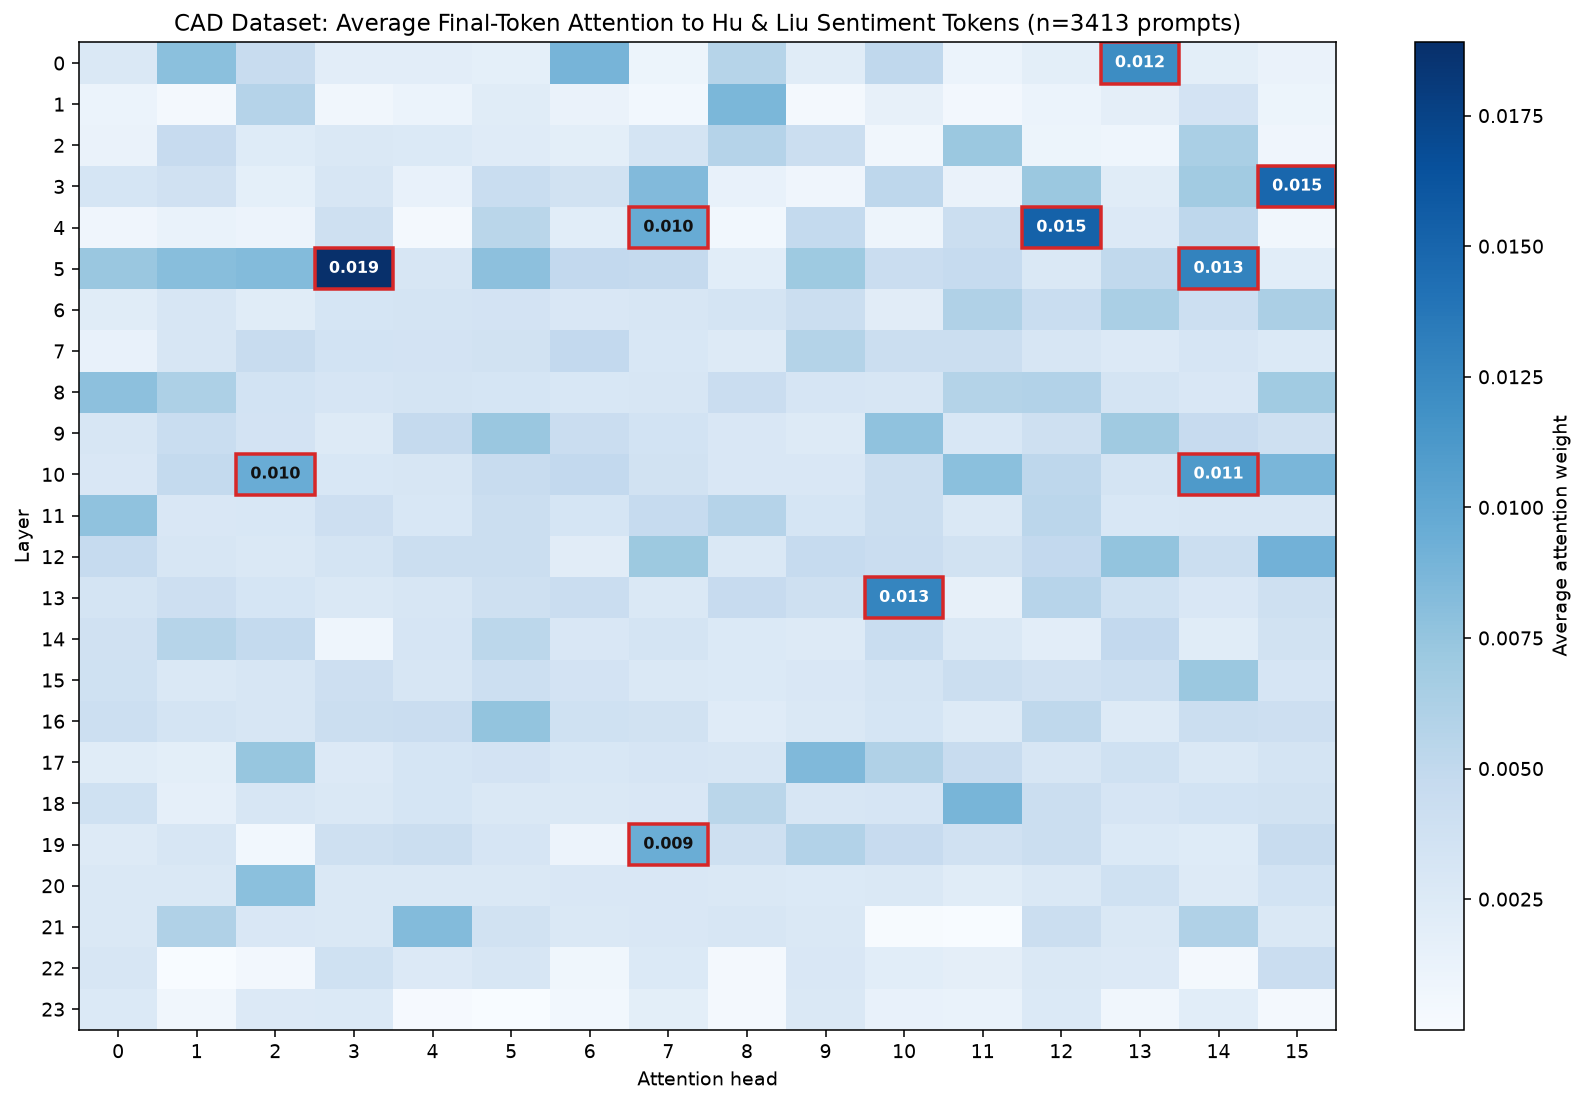

In [88]:
# Analyze how CAD prompts attend to Hu & Liu sentiment words.
# Set this to an integer for a quick subset run, or None for the full CAD dataset.
max_cad_attention_prompts = None
cad_attention_top_k = 10

# The utility loads CAD pairs, prepares Hu & Liu tokens, finds sentiment words
# inside each CAD prompt, averages final-token attention to those words across
# all analyzed prompts, prints the top-k layer/head candidates with standard
# deviation, and saves the average layer/head heatmap.
cad_attention_result = analyze_cad_hu_liu_attention_heads(
    model,
    tokenizer,
    device,
    max_prompts=max_cad_attention_prompts,
    top_k=cad_attention_top_k,
    filename_or_path=config.ATTENTION_CAD_SENTIMENT_HEATMAP_PATH,
)
display_image(config.ATTENTION_CAD_SENTIMENT_HEATMAP_PATH.name)


### Ergebnisinterpretation


## 6. BONUS: Induction Heads suchen

Rank   Layer   Head   Induction score
--------------------------------------
1      5       2      0.443560
2      4       9      0.424863
3      1       14     0.404122
4      3       9      0.398479
5      5       11     0.380464
6      3       1      0.372651
7      1       11     0.365844
8      22      14     0.364238
9      5       4      0.363464
10     5       9      0.355922
Highest induction score: layer 5, head 2 (0.443560)
Saved file: attention_induction_heatmap.png


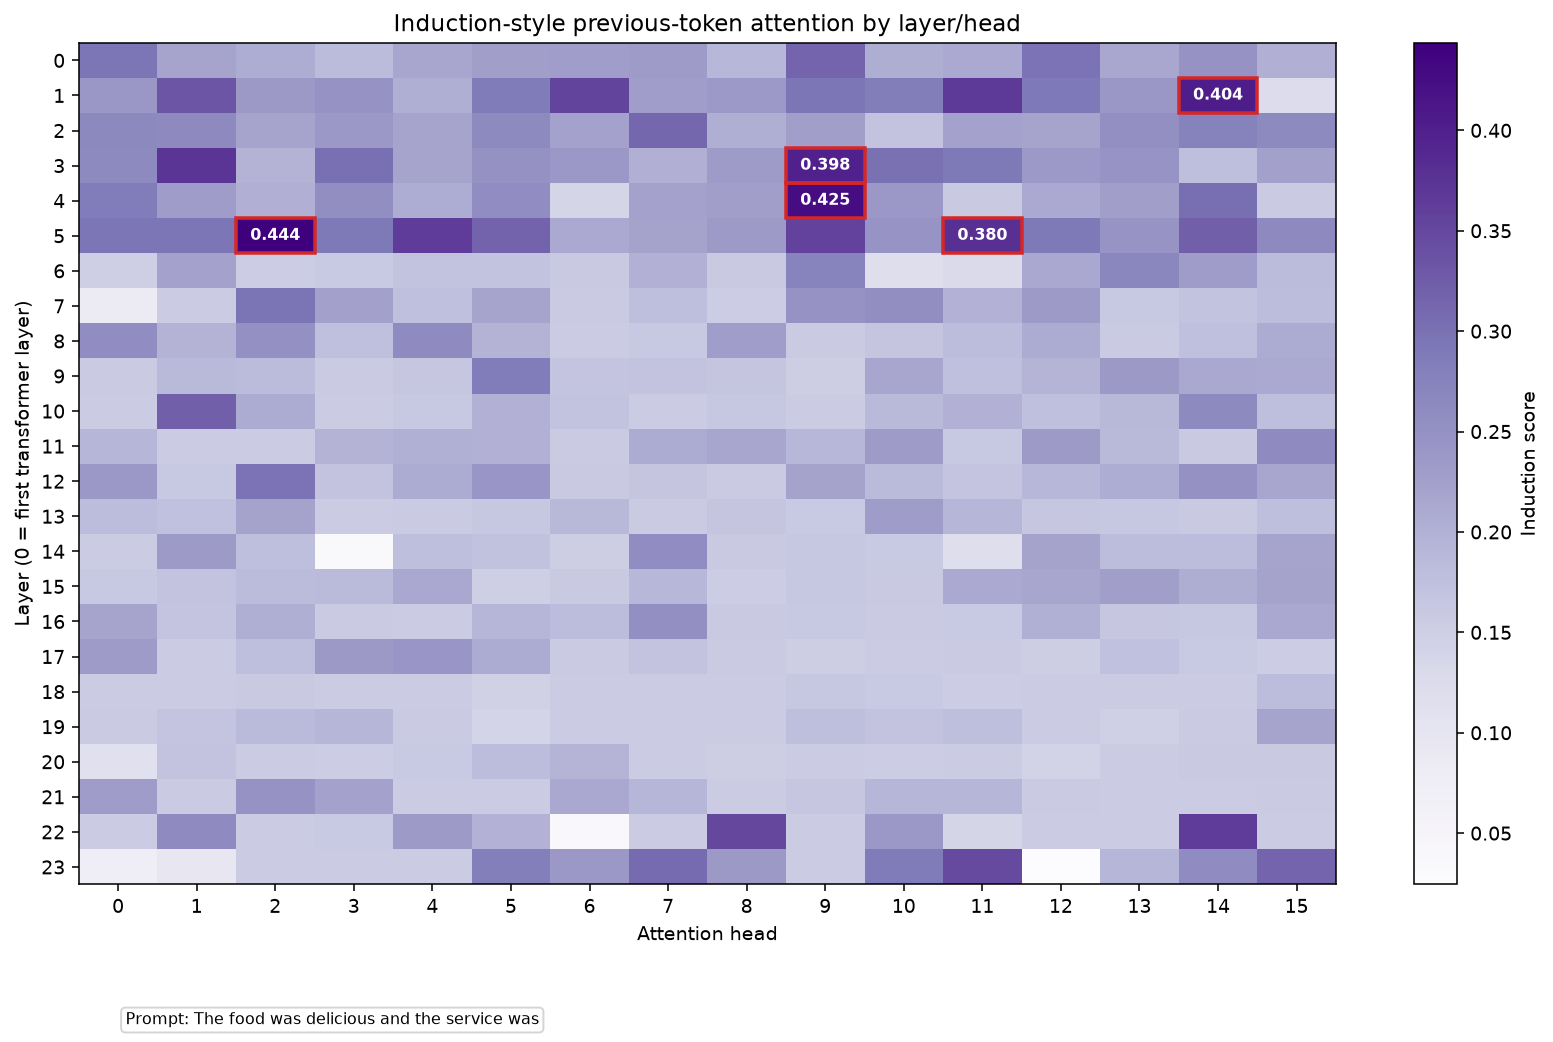

In [89]:
# Analyze whether some attention heads mainly attend to nearby previous tokens.
# The utility computes one induction-style score for every layer/head pair by
# averaging attention on the diagonals for the previous one and previous two
# token positions of each attention matrix.
# It then prints the top-k heads, saves a layer/head heatmap, and displays it below.
# This is a pattern-based diagnostic, not a causal proof that the head is necessary.
induction_result = analyze_induction_heads(
    attentions,
    prompt=prompt,
    top_k=10,
    filename_or_path=config.ATTENTION_INDUCTION_HEATMAP_PATH,
)
display_image(config.ATTENTION_INDUCTION_HEATMAP_PATH.name)


## 7. Zusammenfassung

Die Attention-Analyse wurde durchgeführt, um Attention Heads zu identifizieren, die beim Verarbeiten des Prompts besonders stark auf das sentimenttragende Token *„delicious“* fokussieren. Die Ergebnisse zeigen, dass mehrere Heads in unterschiedlichen Schichten erhöhte Aufmerksamkeit auf dieses Token richten. Die stärkste gemessene Attention wurde in **Layer 6, Head 3** mit einem Gewicht von **0,835** beobachtet. Weitere auffällige Heads treten unter anderem in den Layern 7, 8, 10 und 19 auf.

Die stärksten Subject-Attention-Muster konzentrieren sich überwiegend auf die frühen bis mittleren Schichten des Modells. Dies deutet darauf hin, dass sentimentrelevante Informationen bereits relativ früh aus dem Eingabetext extrahiert werden. In den späteren Schichten nimmt die direkte Aufmerksamkeit auf das Wort *„delicious“* deutlich ab. Gleichzeitig zeigte die zuvor durchgeführte Logit-Lens-Analyse, dass die stärkste Sentiment-Separation erst in den oberen Schichten des Modells entsteht. Dies legt nahe, dass frühe Attention Heads zunächst sentimentrelevante Informationen sammeln, während die späteren Schichten diese Informationen schrittweise zu einer stabilen Sentiment-Repräsentation verdichten.

Die Analyse einzelner Attention-Matrizen zeigt darüber hinaus unterschiedliche Spezialisierungen der Heads. Einige Heads fokussieren sich stark auf einzelne inhaltstragende Tokens, während andere globale Muster wie Satzanfänge oder vorherige Tokens verfolgen. Solche Muster liefern wertvolle Hinweise darauf, welche Informationen innerhalb des Netzwerks transportiert werden.

Allerdings erlaubt die Attention-Analyse allein keine Aussagen über die tatsächliche kausale Bedeutung eines Heads. Hohe Attention-Gewichte bedeuten lediglich, dass ein Head Informationen von einem bestimmten Token bezieht. Daraus folgt jedoch nicht automatisch, dass diese Informationen auch für die finale Modellentscheidung genutzt werden. Attention beschreibt somit primär den Informationsfluss innerhalb des Modells und liefert Hinweise auf potenziell relevante Komponenten, beweist jedoch keine Kausalität.

Um die tatsächliche Bedeutung einzelner Heads oder Schichten für die Sentiment-Vorhersage zu untersuchen, ist daher eine kausale Methode erforderlich. Im Gegensatz zur Attention-Analyse überprüft **Activation Patching**, ob eine bestimmte Aktivierung tatsächlich für die Vorhersage verantwortlich ist, indem Aktivierungen zwischen unterschiedlichen Modellläufen gezielt ausgetauscht werden. Erst dadurch lässt sich feststellen, welche Komponenten einen direkten Beitrag zur Modellentscheidung leisten.

Zusammenfassend zeigt die Attention-Analyse, dass sentimenttragende Tokens bereits in frühen bis mittleren Schichten stark berücksichtigt werden. Die eigentliche Herausbildung einer stabilen Sentiment-Repräsentation scheint jedoch erst in den späteren Schichten stattzufinden. Die identifizierten Heads stellen daher geeignete Kandidaten für die anschließende kausale Untersuchung mittels Activation Patching dar.